In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

files = list(Path("../data").glob("*.json"))

dfs = []
for f in files:
    with open(f, "r", encoding="utf-8") as file:
        dfs.append(pd.DataFrame(json.load(file)))

df = pd.concat(dfs, ignore_index=True)
df.head()


,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode
0,2015-01-14T14:43:51Z,"Android OS 4.4.4 API 19 (HUAWEI, G620S-L01)",28835,FR,77.84.112.102,I Can't Lie,Maroon 5,Hands All Over,spotify:track:4fUaRSXgRYGqn08ejkOg3a,None,...,None,None,None,appload,appload,False,True,False,NaN,False
1,2015-01-14T14:46:54Z,"Android OS 4.4.4 API 19 (HUAWEI, G620S-L01)",183906,FR,77.84.112.102,Cosmo,Soprano,Cosmopolitanie,spotify:track:2XuQL2G6waqiSgHotdoWVi,None,...,None,None,None,appload,trackdone,False,False,False,NaN,False
2,2015-01-14T14:47:14Z,"Android OS 4.4.4 API 19 (HUAWEI, G620S-L01)",20154,FR,77.84.112.102,Préface,Soprano,Cosmopolitanie,spotify:track:5TnWefsI206pQax3mKRHrg,None,...,None,None,None,trackdone,endplay,True,True,False,NaN,False
3,2015-01-14T14:47:35Z,"Android OS 4.4.4 API 19 (HUAWEI, G620S-L01)",14523,FR,77.84.112.102,Ladykiller,Maroon 5,Overexposed Track By Track,spotify:track:3Uum6BJBgb7Fp3uXmlTFuC,None,...,None,None,None,appload,endplay,False,True,False,NaN,False
4,2015-01-14T14:48:15Z,"Android OS 4.4.4 API 19 (HUAWEI, G620S-L01)",31772,FR,77.84.112.102,How,Maroon 5,Hands All Over,spotify:track:7LuTV8ZSxGEBIeW01v8hfv,None,...,None,None,None,appload,appload,False,True,False,NaN,False


In [18]:
# Convert ts from text to a datetime object
df["ts"] = pd.to_datetime(df["ts"], errors="coerce")

# Milliseconds → minutes (easier to understand)
df["minutesPlayed"] = df["ms_played"] / 60_000

print(f"Loaded {len(df):,} rows")
df.head(10)

df["year"] = df["ts"].dt.year
df["month"] = df["ts"].dt.month
df["day"] = df["ts"].dt.day
df["hour"] = df["ts"].dt.hour

df.head()

Loaded 82,010 rows


,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,shuffle,skipped,offline,offline_timestamp,incognito_mode,year,month,day,hour,minutesPlayed
0,2015-01-14 14:43:51+00:00,"Android OS 4.4.4 API 19 (HUAWEI, G620S-L01)",28835,FR,77.84.112.102,I Can't Lie,Maroon 5,Hands All Over,spotify:track:4fUaRSXgRYGqn08ejkOg3a,None,...,False,True,False,NaN,False,2015,1,14,14,0.480583
1,2015-01-14 14:46:54+00:00,"Android OS 4.4.4 API 19 (HUAWEI, G620S-L01)",183906,FR,77.84.112.102,Cosmo,Soprano,Cosmopolitanie,spotify:track:2XuQL2G6waqiSgHotdoWVi,None,...,False,False,False,NaN,False,2015,1,14,14,3.065100
2,2015-01-14 14:47:14+00:00,"Android OS 4.4.4 API 19 (HUAWEI, G620S-L01)",20154,FR,77.84.112.102,Préface,Soprano,Cosmopolitanie,spotify:track:5TnWefsI206pQax3mKRHrg,None,...,True,True,False,NaN,False,2015,1,14,14,0.335900
3,2015-01-14 14:47:35+00:00,"Android OS 4.4.4 API 19 (HUAWEI, G620S-L01)",14523,FR,77.84.112.102,Ladykiller,Maroon 5,Overexposed Track By Track,spotify:track:3Uum6BJBgb7Fp3uXmlTFuC,None,...,False,True,False,NaN,False,2015,1,14,14,0.242050
4,2015-01-14 14:48:15+00:00,"Android OS 4.4.4 API 19 (HUAWEI, G620S-L01)",31772,FR,77.84.112.102,How,Maroon 5,Hands All Over,spotify:track:7LuTV8ZSxGEBIeW01v8hfv,None,...,False,True,False,NaN,False,2015,1,14,14,0.529533


The Big Picture

In [20]:
total_hours = df["ms_played"].sum() / 60
unique_artists = df["master_metadata_album_artist_name"].nunique()
unique_tracks = df["master_metadata_track_name"].nunique()
date_range = f"{df['ts'].min():%b %d, %Y} — {df['ts'].max():%b %d, %Y}"

print(f"Date range:      {date_range}")
print(f"Total listening:  {total_hours:,.0f} hours")
print(f"Unique artists:  {unique_artists:,}")
print(f"Unique tracks:   {unique_tracks:,}")

Date range:      Jan 14, 2015 — Mar 13, 2026
Total listening:  172,721,656 hours
Unique artists:  3,013
Unique tracks:   8,139


Top artists

In [22]:
#Most listened artists

top_artists = (
    df.groupby("master_metadata_album_artist_name")["minutesPlayed"] \
  .sum().sort_values(ascending=False).head(10)
)

top_artists

master_metadata_album_artist_name
Bad Bunny            10151.257250
Mora                  3735.387767
Leiva                 3062.750083
Fito y Fitipaldis     2625.787617
Quevedo               2498.616717
Rauw Alejandro        2318.781767
Myke Towers           2083.952783
Olivia Rodrigo        1968.863950
Pereza                1949.321750
El Canto Del Loco     1808.762300
Name: minutesPlayed, dtype: float64

Top tracks

In [23]:
#Most listened songs

top_tracks = (
    df.groupby("master_metadata_track_name")["minutesPlayed"] \
  .sum().sort_values(ascending=False).head(10)
)

top_tracks

master_metadata_track_name
drivers license                     587.038417
BAILE INoLVIDABLE                   524.458700
Antes de que cuente diez            517.708833
El Fin del Mundo                    497.280733
LA INOCENTE                         493.472400
Flaca                               478.124500
Soldadito marinero                  470.309633
Marta, Sebas, Guille y los demás    452.923317
Hasta Que Dios Diga                 426.581900
Columbia                            415.176600
Name: minutesPlayed, dtype: float64

Hour of day

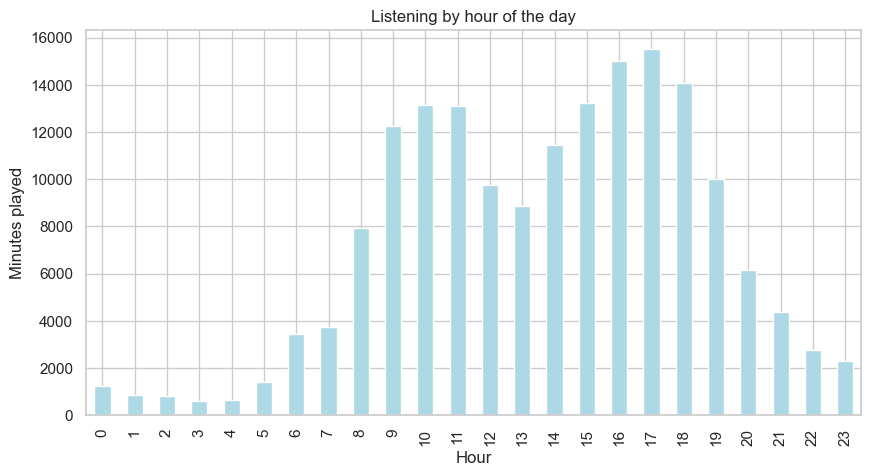

In [40]:
#Hours of the day where I listen the most music

plt.figure(figsize=(10,5))
df.groupby("hour")["minutesPlayed"].sum().plot(kind="bar", color="lightblue")
plt.title("Listening by hour of the day")
plt.xlabel("Hour")
plt.ylabel("Minutes played")
plt.show()

Day of week

C:\Users\aitan\AppData\Local\Temp\ipykernel_87352\3641125899.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("dayOfWeek")["minutesPlayed"].sum().plot(kind="bar", color="lightgreen")


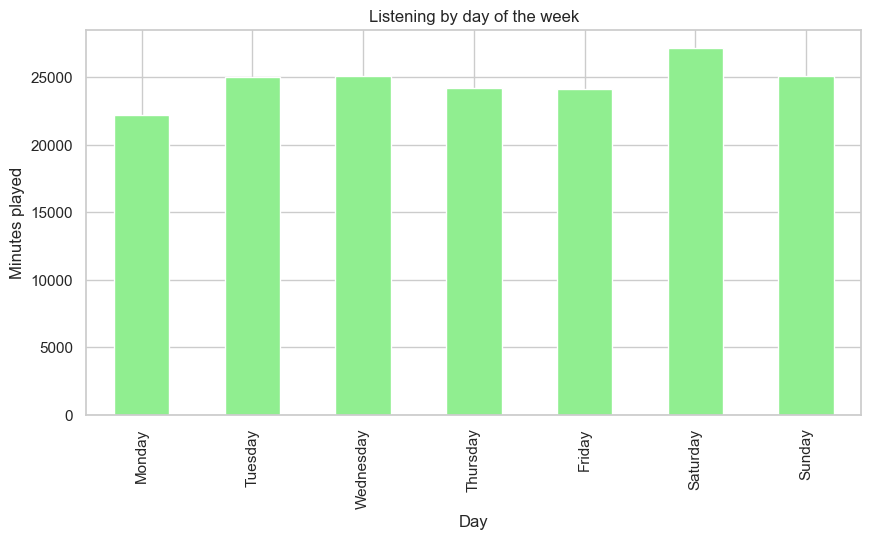

In [35]:
df["dayOfWeek"] = df["ts"].dt.day_name()

ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["dayOfWeek"] = pd.Categorical(df["dayOfWeek"], categories=ordered_days, ordered=True)

plt.figure(figsize=(10,5))
df.groupby("dayOfWeek")["minutesPlayed"].sum().plot(kind="bar", color="lightgreen")
plt.title("Listening by day of the week")
plt.xlabel("Day")
plt.ylabel("Minutes played")
plt.show()

Month

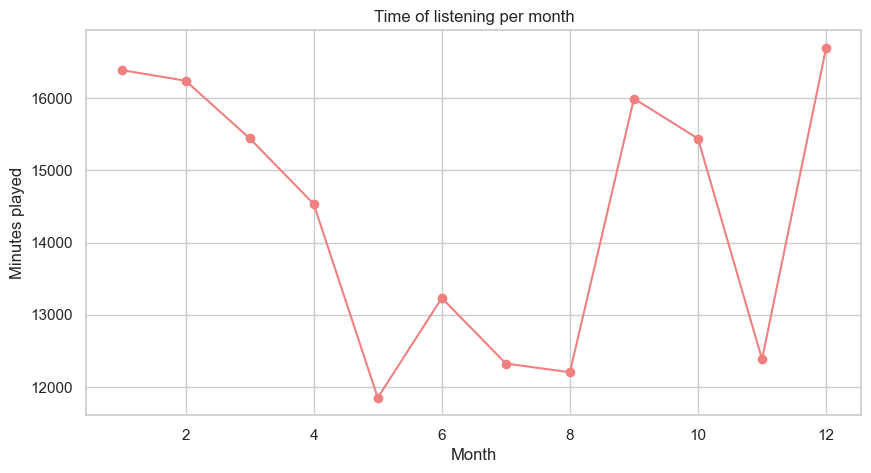

In [39]:
#Time of music listening per month

plt.figure(figsize=(10,5))
df.groupby("month")["minutesPlayed"].sum().plot(kind="line", marker="o", color="lightcoral")
plt.title("Time of listening per month")
plt.xlabel("Month")
plt.ylabel("Minutes played")
plt.show()